## Data Preprocessing


In [6]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#import Scikit-learn modules
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [8]:
#load merged net position financial csv file dataset for eda
netposition_dataset = pd.read_csv("../../data/processed-data/Net_positions_reliability_binary.csv")
#convert csv file into a dataframe
netposition_df = pd.DataFrame(netposition_dataset)
#print first few rows of dataframe
print(netposition_df.head())
#print columns of dataframe
print(netposition_df.columns)


#load merged revenue financial csv file dataset for eda
revenue_dataset = pd.read_csv("../../data/processed-data/Revenue_reliability_binary.csv")
#convert csv file into a dataframe
revenue_df = pd.DataFrame(revenue_dataset)
#print first few rows of dataframe
print(revenue_df.head())
#print columns of dataframe
print(revenue_df.columns)


#load merged expenses financial csv file dataset for eda
expenses_dataset = pd.read_csv("../../data/processed-data/Expenses_reliability_binary.csv")
#convert csv file into a dataframe
expenses_df = pd.DataFrame(expenses_dataset)
#print first few rows of dataframe
print(expenses_df.head())
#print columns of dataframe
print(expenses_df.columns)


#load merged debts financial csv file dataset for eda
debts_dataset = pd.read_csv("../../data/processed-data/Debts_reliability_binary.csv")
#convert csv file into a dataframe
debts_df = pd.DataFrame(debts_dataset)
#print first few rows of dataframe
print(debts_df.head())
#print columns of dataframe
print(debts_df.columns)

   Unnamed: 0 Statements of Revenue, Expenses and Changes in Net Position  \
0           0                        Revenue from transportation            
1           1                           Total operating revenues            
2           2                            Transportation services            
3           3                           Other operating expenses            
4           4   Total operating expenses, excluding depreciation            

         Date  Net Position Amounts (USD)  ontime_trip_count  trip_count  \
0  2023-06-30                      376357               2925        3297   
1  2023-06-30                      452973               2925        3297   
2  2023-06-30                      822671               2925        3297   
3  2023-06-30                      968312               2925        3297   
4  2023-06-30                     1790983               2925        3297   

          Time  Pre and Post 2021  Pre and Post 2021 Binary  
0  04:00:00+00    

## Part 1: Dimensionality Reduction

In [10]:
#drop unneeded columns
netposition_df_drop = netposition_df.drop(["Unnamed: 0", "Pre and Post 2021"],axis=1)
revenue_df_drop = revenue_df.drop(["Unnamed: 0", "Pre and Post 2021"],axis=1)
expenses_df_drop = expenses_df.drop(["Unnamed: 0", "Pre and Post 2021"],axis=1)
debts_df_drop = debts_df.drop(["Unnamed: 0", "Pre and Post 2021"],axis=1)

In [12]:
#subset the net position data, select numerical feature
X_netposition = netposition_df_drop.select_dtypes(include=[np.number])
print(X_netposition.head())


   Net Position Amounts (USD)  ontime_trip_count  trip_count  \
0                      376357               2925        3297   
1                      452973               2925        3297   
2                      822671               2925        3297   
3                      968312               2925        3297   
4                     1790983               2925        3297   

   Pre and Post 2021 Binary  
0                         1  
1                         1  
2                         1  
3                         1  
4                         1  


In [31]:
#subset the revenue data, select numerical feature
X_rev = revenue_df_drop.select_dtypes(include=[np.number])
print(X_rev.columns)

Index(['Revenue (USD)', 'ontime_trip_count', 'trip_count',
       'Pre and Post 2021 Binary'],
      dtype='object')


In [36]:
#subset the expenses data, select numerical feature
X_exp = expenses_df_drop.select_dtypes(include=[np.number])
print(X_exp.columns)

Index(['Expenses (USD)', 'ontime_trip_count', 'trip_count',
       'Pre and Post 2021 Binary'],
      dtype='object')


In [43]:
#subset the expenses data, select numerical feature
X_debts = debts_df_drop.select_dtypes(include=[np.number])
print(X_debts.columns)

Index(['Debt (USD)', 'ontime_trip_count', 'trip_count',
       'Pre and Post 2021 Binary'],
      dtype='object')


In [25]:
#test attempt
#select the "Net Position Amounts (USD)" and "ontime_trip_count for pca
#and reshape the data to fit in pca standardization
#X = netposition_df_drop["Net Position Amounts (USD)"].values.reshape(-1,1)
#y = netposition_df_drop["ontime_trip_count"].values.reshape(-1,1)

In [13]:
#standardize the net position data
#pca reduces data dimensionality by fitting PCA model and transforming X 
scaler = StandardScaler()
X_netposition_scaled = scaler.fit_transform(X_netposition)

#Fit PCA to the standardized net position dataset
pca = PCA(n_components=4) #4 features
X_netposition_pca = pca.fit_transform(X_netposition_scaled)


In [33]:
#standardize the revenue data
#pca reduces data dimensionality by fitting PCA model and transforming X 
X_rev_scaled = scaler.fit_transform(X_rev)

#Fit PCA to the standardized net position dataset
pca_rev = PCA(n_components=4) #4 features
X_rev_pca = pca_rev.fit_transform(X_rev_scaled)


In [40]:
#standardize the expenses data
#pca reduces data dimensionality by fitting PCA model and transforming X 
X_exp_scaled = scaler.fit_transform(X_exp)

#Fit PCA to the standardized net position dataset
pca_exp = PCA(n_components=4) #4 features
X_exp_pca = pca_exp.fit_transform(X_exp_scaled)


In [45]:
#standardize the expenses data
#pca reduces data dimensionality by fitting PCA model and transforming X 
X_debts_scaled = scaler.fit_transform(X_debts)

#Fit PCA to the standardized net position dataset
pca_debts = PCA(n_components=4) #4 features
X_debts_pca = pca_debts.fit_transform(X_debts_scaled)

In [28]:
#test attempt
#standardize the data
#X_netposition_scaled2 = scaler.fit_transform(X)
#X_netposition_scaled2y = scaler.fit_transform(y)

#fit pca to feature of net position dataset
#pca_net = PCA(n_components=1)
#X_netposition_pca2 = pca_net.fit_transform(X_netposition_scaled2)


## Model Evaluation Metrics:

In [15]:
#net position dataset
#get explained variance ratio
print("Explained variance ratio: ", pca.explained_variance_ratio_)

#get total variance explained
print("Total explained variance", np.sum(pca.explained_variance_ratio_))

Explained variance ratio:  [0.60435545 0.23362566 0.15930919 0.00270969]
Total explained variance 0.9999999999999999


In [34]:
#revenue dataset
#get explained variance ratio
print("Explained variance ratio: ", pca_rev.explained_variance_ratio_)

#get total variance explained
print("Total explained variance", np.sum(pca_rev.explained_variance_ratio_))

Explained variance ratio:  [0.57747761 0.25691962 0.16257182 0.00303095]
Total explained variance 0.9999999999999999


In [41]:
#expenses dataset
#get explained variance ratio
print("Explained variance ratio: ", pca_exp.explained_variance_ratio_)

#get total variance explained
print("Total explained variance", np.sum(pca_exp.explained_variance_ratio_))

Explained variance ratio:  [0.58814127 0.24983423 0.1593151  0.00270939]
Total explained variance 1.0


In [46]:
#debts dataset
#get explained variance ratio
print("Explained variance ratio: ", pca_debts.explained_variance_ratio_)

#get total variance explained
print("Total explained variance", np.sum(pca_debts.explained_variance_ratio_))

Explained variance ratio:  [6.17549998e-01 2.30211007e-01 1.52222417e-01 1.65787771e-05]
Total explained variance 1.0


## Results

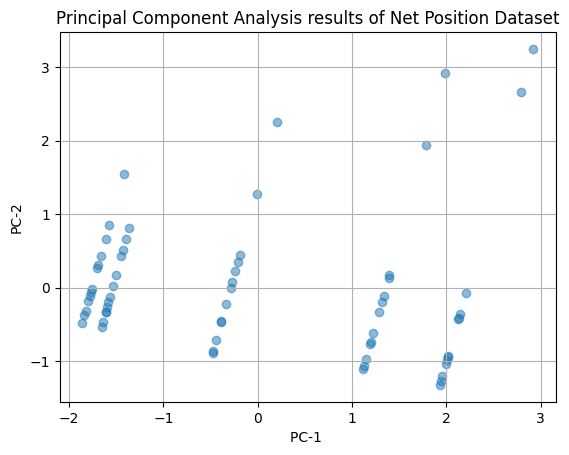

In [20]:
#plot pca applied to the standardized net position dataset
# visualize the results
fig, ax = plt.subplots()
ax.scatter(X_netposition_pca[:,0], X_netposition_pca[:,1], alpha=0.5)
ax.set(xlabel='PC-1 ', ylabel='PC-2',
title='Principal Component Analysis results of Net Position Dataset')
ax.grid()
plt.show()

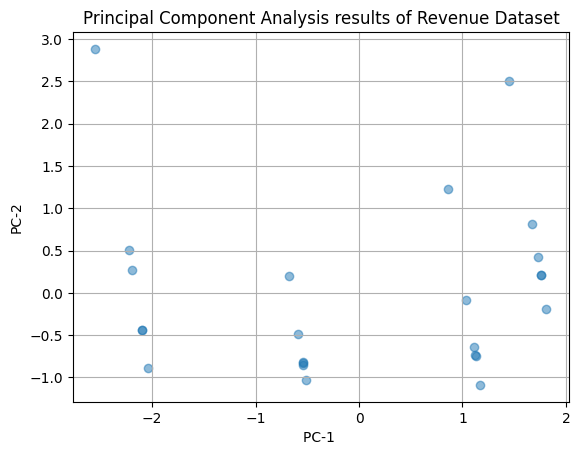

In [35]:
#plot pca applied to the standardized revenue dataset
#visualize the results
fig_rev, ax_rev = plt.subplots()
ax_rev.scatter(X_rev_pca[:,0], X_rev_pca[:,1], alpha=0.5)
ax_rev.set(xlabel='PC-1 ', ylabel='PC-2',
title='Principal Component Analysis results of Revenue Dataset')
ax_rev.grid()
plt.show()

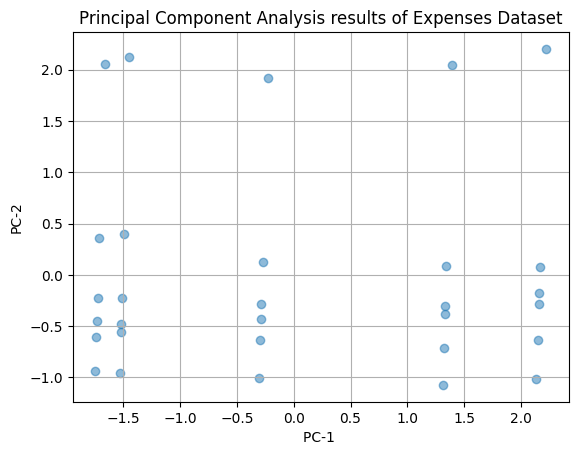

In [42]:
#plot pca applied to the standardized expenses dataset
#visualize the results
fig_exp, ax_exp = plt.subplots()
ax_exp.scatter(X_exp_pca[:,0], X_exp_pca[:,1], alpha=0.5)
ax_exp.set(xlabel='PC-1 ', ylabel='PC-2',
title='Principal Component Analysis results of Expenses Dataset')
ax_exp.grid()
plt.show()

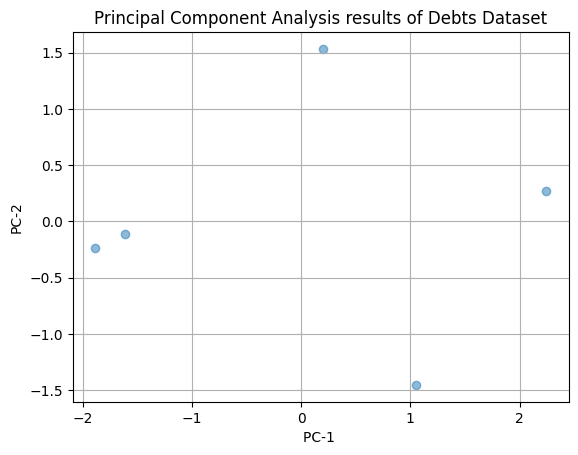

In [47]:
#plot pca applied to the standardized debts dataset
#visualize the results
fig_debts, ax_debts = plt.subplots()
ax_debts.scatter(X_debts_pca[:,0], X_debts_pca[:,1], alpha=0.5)
ax_debts.set(xlabel='PC-1 ', ylabel='PC-2',
title='Principal Component Analysis results of Debts Dataset')
ax_debts.grid()
plt.show()

## Discussion